# Change root directory

In [1]:
import os
root_dir = os.path.dirname(os.path.abspath(''))
os.chdir(root_dir)
print(f"Directory changed to: {os.getcwd()}")

Directory changed to: /home/bespi123/git/helmholtzCoilsDesigner


In [2]:
import time
import numpy as np
import pandas as pd
from src import helmCoils_simulator as sim
from src import plotMagneticField as hplot
from src import helmCoils_optmizer as opt
import matplotlib.pyplot as plt
import plotly.graph_objs as go

# Optimization to achieve a work space of 30cm

In [3]:
number_of_spires = 2
size_length =  0.72
distance_among_spires = 0.46
turns = [30, 30]
current = 1 
rotation_matrix = np.eye(3)
X_coil = sim.CoilParameters(number_of_spires, size_length, distance_among_spires, turns, current, rotation_matrix)

# Simulation settings
parallel_coils = 150
batch_Size = 120
grid_length_size = 0.01 #Space among evaluation points
num_seg = 100           #Numer of segments 

In [4]:
##Spawn spires
spires_x_sq = X_coil.square_spires(num_seg)

In [5]:
f0 = None
f0 = hplot.plot_spires(f0, spires_x_sq, color='black', row=None, col=None)

# Plot the square spires
f0.show()

In [6]:
X, Y, Z = sim.generate_range([-0.5, 0.5], [-0.5, 0.5], [-0.5, 0.5], step_size_x = grid_length_size)

hplot.plot_grid(X, Y, Z, f0)

In [ ]:
optimizer = opt.HelmholtzOptimizer(
    desired_size = 0.30,          # 30e-2 is 0.30 m
    coil = X_coil,
    fun = X_coil.square_spires,
    #fun = X_coil.circular_spires,
    fix_L=False,
    fixed_L_value=2.0,          # Set a fixed value for L if needed
    grid_length_size=grid_length_size,
    population = 20,
    generations = 100,
    mutation = 0.8,
    penalty = 5000,
    initial_values=[1.05, 0.59]
)
result = optimizer.optimize()

In [ ]:
a = pd.DataFrame(result[3])
# Create plot with two curves
plt.figure(figsize=(10, 6))
plt.plot(a['gen'], a['min'], label='Minimum', marker='o', linestyle='-', linewidth=1.5)
#plt.plot(a['gen'], a['avg'], label='Average', marker='x', linestyle='--', linewidth=1.5)

# Add labels and details
plt.title("Fitness Evolution per Generation")
plt.xlabel("Generation")
plt.ylabel("Fitness")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


# Simulate Results

In [7]:
## Update obtained parameters to the models
X_coil.update_parameters(length=1.05 ,distance=0.59)
##Spawn spires
spires_x_sq = X_coil.square_spires(num_seg)
f1 = None
f1 = hplot.plot_spires(f1, spires_x_sq, color='black', row=None, col=None)

# Plot the square spires
f1.show()

In [8]:
# Grid generation for simulation
X, Y, Z = sim.generate_range([-0.6, 0.6],[-0.6, 0.6], [-0.6, 0.6], step_size_x = grid_length_size)

hplot.plot_grid(X, Y, Z, f0)

In [9]:
#Run simulations
start_time = time.time() #Count start time
x_coil_results_s = sim.coil_simulation_parallel(X, Y, Z, X_coil, spires_x_sq, batch_Size, enable_progress_bar=True, n=parallel_coils)

end_time = time.time()   #Mark ending time

# Calcular la norma del campo magnético B = sqrt(Bx^2 + By^2 + Bz^2)
x_coil_results_s["B_norm"] = np.sqrt(x_coil_results_s["Bx"]**2 + x_coil_results_s["By"]**2 + x_coil_results_s["Bz"]**2)

#Calculate and show the simulation time
execution_time = end_time - start_time
print(f'Simulation finished in {execution_time/60} minutes...')

# Save results in a CSV file
output_file = 'data/triaxial_coil_results_square.csv'
x_coil_results_s.to_csv(output_file, index=False)

Simulation Progress: 100%|██████████| 376/376 [00:42<00:00,  8.85it/s]


Simulation finished in 0.7091002027193706 minutes...


In [10]:
# Read data from previous simulations
x_coil_results_s = pd.read_csv('data/triaxial_coil_results_square.csv')

reference_value:  4.566225691460751e-05


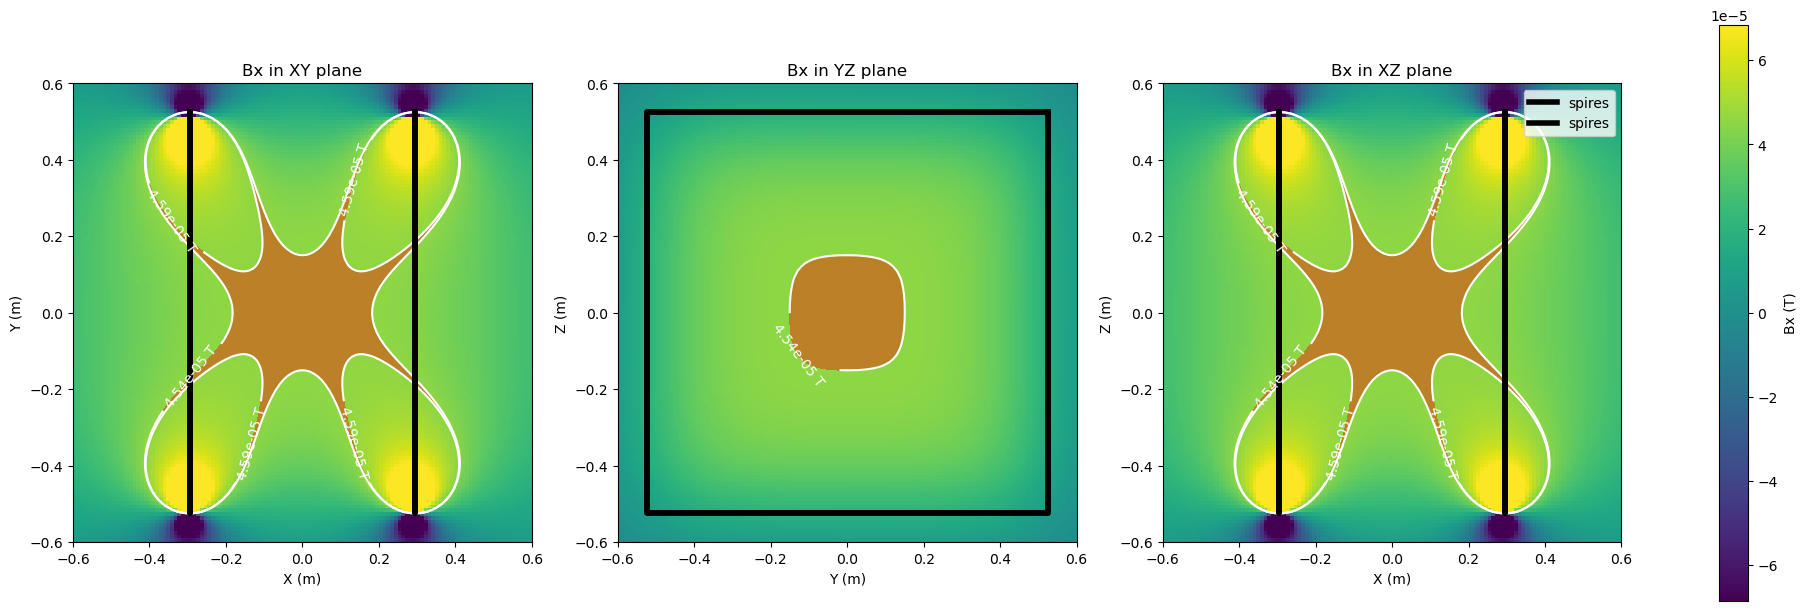

In [20]:
# Print the Bx component
hplot.plot_2d_magnetic_field(x_coil_results_s, spires_x_sq, index='Bx', use_fixed_zaxis=True)

In [19]:
hplot.simple_3d_surface_plot(x_coil_results_s, spires_x_sq, 'Bz', False)

reference_value:  0.0


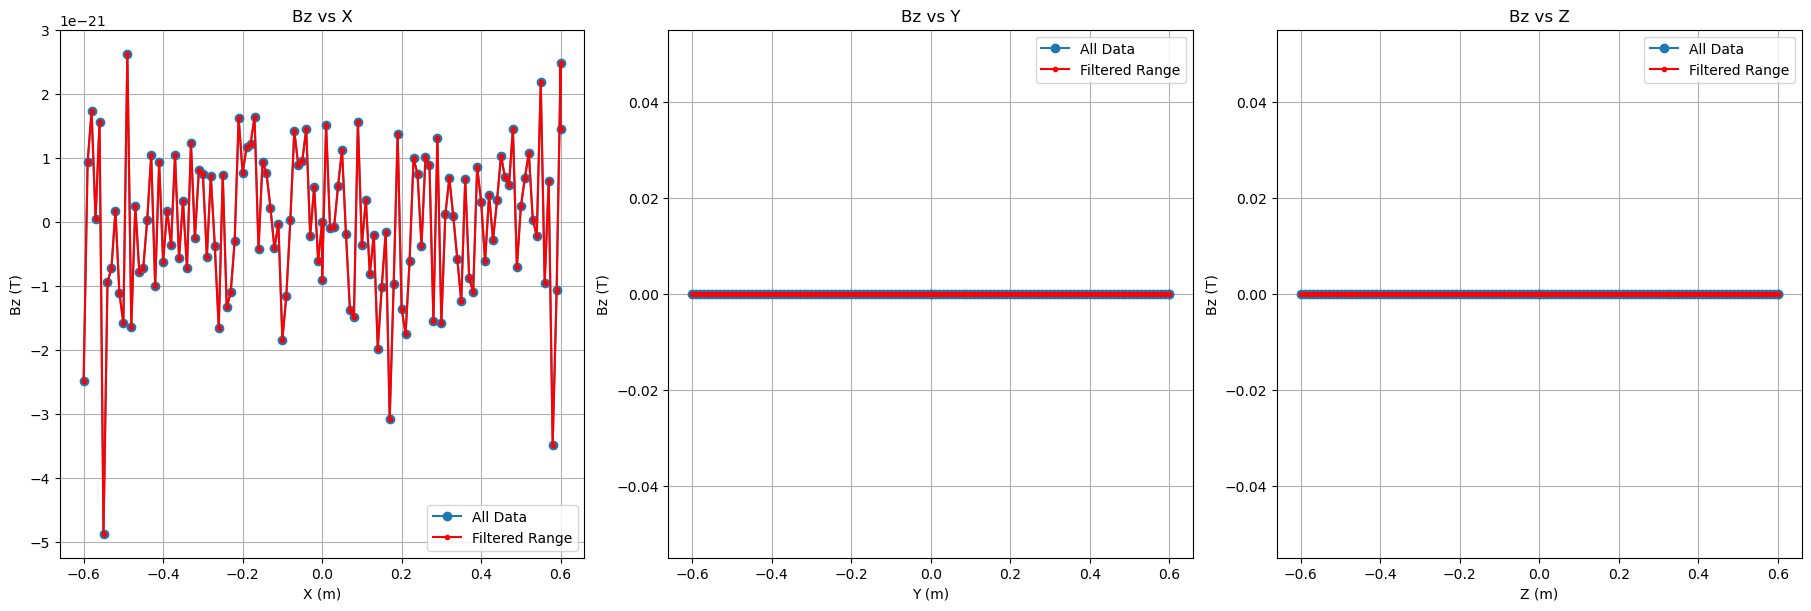

In [14]:
hplot.plot_mainAxis_field(x_coil_results_s, index='Bz')

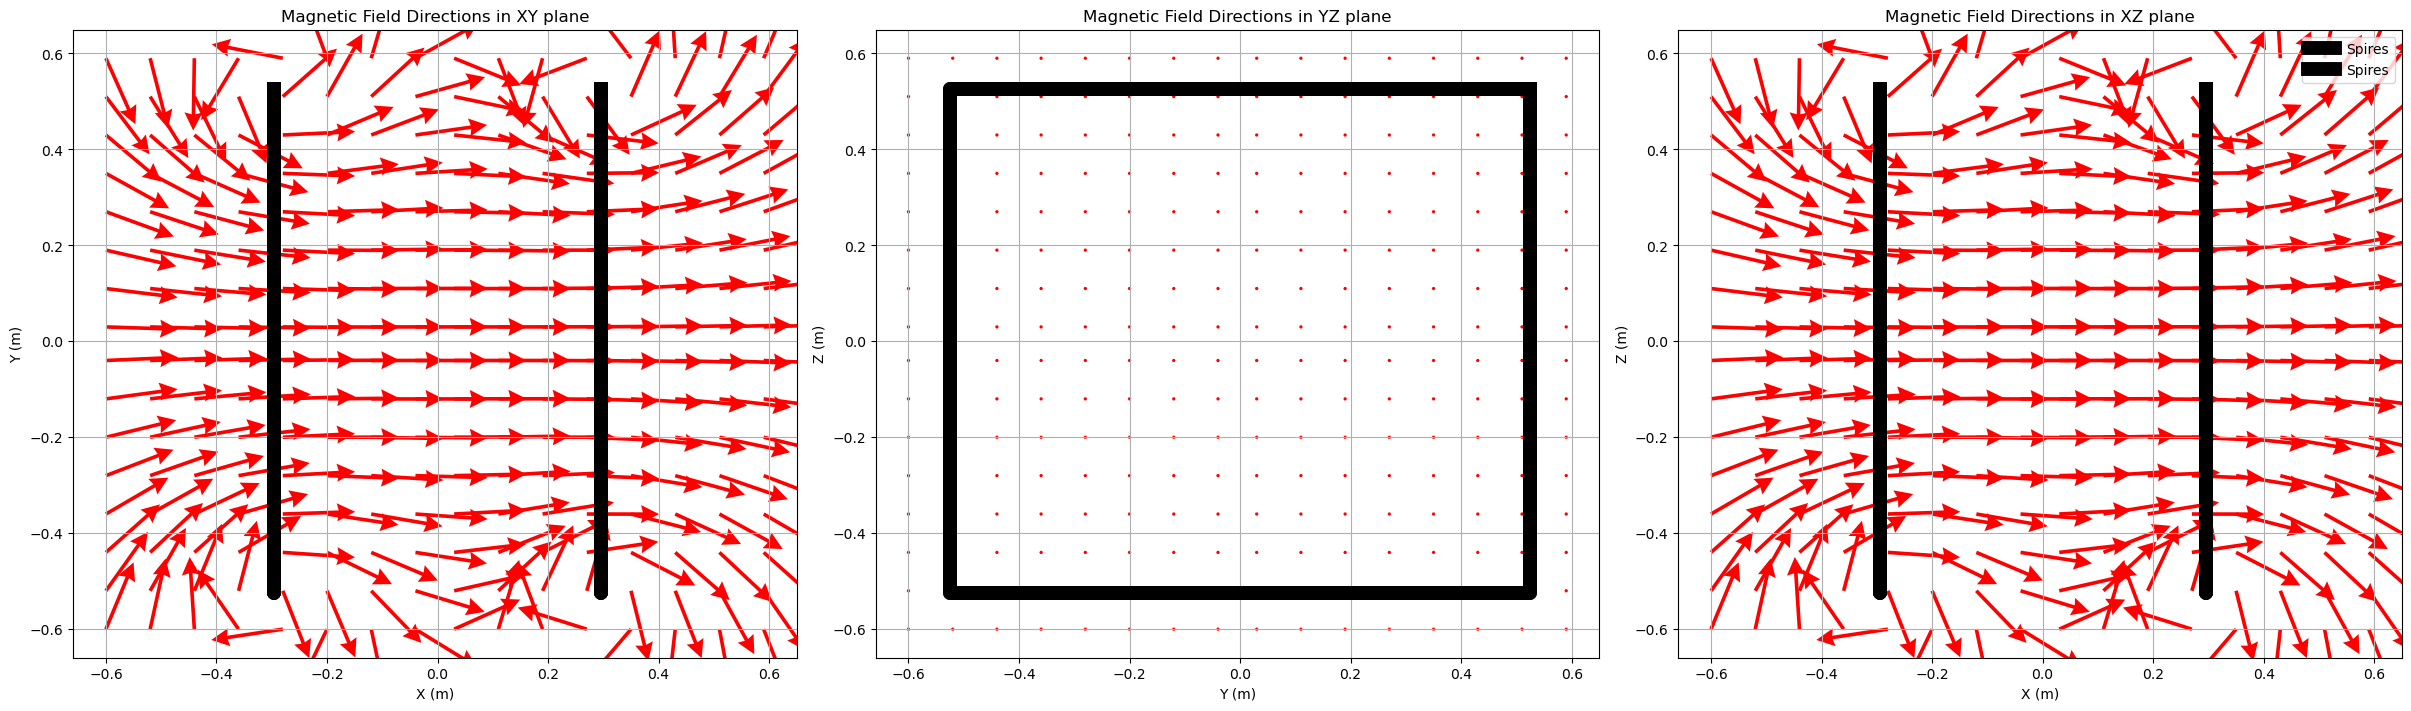

In [15]:
hplot.plot_magnetic_field_directions(x_coil_results_s, spires_x_sq)